# Competitive Intel Summarizer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/competitive-intel/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/competitive-intel/demo.ipynb)

> Turn scattered competitor notes into one comparison matrix + strategic takeaways.

Most teams "track competitors" as a graveyard of screenshots and Slack links. This tool
turns raw competitor copy into a structured **feature matrix** and a short list of
**strategic takeaways** - the artifact you can actually put in front of a product review.

**What this notebook covers**
1. Extracting a structured profile (pricing, features, market) from raw text
2. Building an aligned feature matrix across competitors
3. Auto-surfacing takeaways: white space, feature leader, pricing patterns
4. A heatmap of who has what
5. The Claude upgrade for sharper synthesis
6. Try your own competitors


## Step 1 - Extract a profile from raw text

Each competitor arrives as a paragraph of site copy or notes. We scan it against a fixed
**feature lexicon** so every competitor is measured on the same axes - that alignment is
what makes the later matrix meaningful.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field


@dataclass
class CompetitorProfile:
    name: str
    pricing: list = field(default_factory=list)
    features: list = field(default_factory=list)
    target_market: str = ""
    positioning: str = ""


_PRICE = re.compile(r"\$\s?\d[\d,]*(?:\.\d+)?(?:\s?/\s?(?:mo|month|user|yr|year|seat))?", re.I)
_PLAN = re.compile(r"\b(free|freemium|starter|basic|pro|team|business|enterprise|premium)\b", re.I)

FEATURE_LEXICON = {
    "API access": re.compile(r"\bAPI\b", re.I),
    "SSO / SAML": re.compile(r"\b(sso|saml|single sign)\b", re.I),
    "Integrations": re.compile(r"\bintegrat", re.I),
    "Analytics / reporting": re.compile(r"\b(analytics|dashboard|reporting|insights)\b", re.I),
    "Mobile app": re.compile(r"\b(mobile app|ios|android)\b", re.I),
    "Automation / workflows": re.compile(r"\b(automat|workflow)\b", re.I),
    "Collaboration": re.compile(r"\b(collaborat|teams|shared|comment)\b", re.I),
    "AI features": re.compile(r"\b(ai|machine learning|ml|gpt|llm|copilot)\b", re.I),
    "Security / compliance": re.compile(r"\b(soc 2|gdpr|hipaa|encrypt|compliance)\b", re.I),
    "Free tier": re.compile(r"\b(free tier|free plan|free forever|freemium)\b", re.I),
}

_MARKET = re.compile(r"\b(for\s+(?:small|enterprise|mid-market|startups?|smbs?|teams?|"
                     r"developers?|marketers?|agencies|freelancers)[^.]{0,40})", re.I)


def extract_profile(name, text):
    prices = list(dict.fromkeys(_PRICE.findall(text)))
    plans = list(dict.fromkeys(m.group(0).title() for m in _PLAN.finditer(text)))
    pricing = prices + [p for p in plans if p.lower() not in " ".join(prices).lower()]
    features = [f for f, pat in FEATURE_LEXICON.items() if pat.search(text)]
    m = _MARKET.search(text)
    first = re.split(r"(?<=[.!?])\s+", text.strip())[0] if text.strip() else ""
    return CompetitorProfile(name, pricing[:6], features,
                             m.group(1).strip() if m else "", first[:160])


SAMPLE_COMPETITORS = {
    "FlowCRM": "FlowCRM is a CRM for small teams and startups. Plans: Free, Pro at "
               "$29/user/mo, and Business at $59/user/mo. Includes a REST API, Zapier "
               "integrations, mobile app for iOS and Android, and pipeline analytics. SOC 2 compliant.",
    "Salesboard": "Salesboard is an enterprise sales platform for mid-market and enterprise "
                  "teams. Pricing is custom / enterprise only. Offers SSO and SAML, advanced "
                  "reporting dashboards, workflow automation, and AI-powered lead scoring. GDPR and HIPAA ready.",
    "LeadJar": "LeadJar is a lightweight lead tracker for freelancers and agencies. Free "
               "forever plan plus a Premium tier at $15/mo. Simple contact management with "
               "email integrations. No mobile app yet.",
}

for name, text in SAMPLE_COMPETITORS.items():
    p = extract_profile(name, text)
    print(f"{p.name:<12} {p.target_market}")
    print("   pricing :", ", ".join(p.pricing))
    print("   features:", ", ".join(p.features), "\n")


FlowCRM      for small teams and startups
   pricing : $29/user, $59/user, Free, Pro, Business
   features: API access, Integrations, Analytics / reporting, Mobile app, Collaboration, Security / compliance 

Salesboard   for mid-market and enterprise teams
   pricing : Enterprise
   features: SSO / SAML, Analytics / reporting, Automation / workflows, Collaboration, AI features, Security / compliance 

LeadJar      for freelancers and agencies
   pricing : $15/mo, Free, Premium
   features: Integrations, Mobile app, Free tier 



## Step 2 - Build the aligned feature matrix

Because every profile was scored on the same lexicon, we can pivot into a
feature × competitor grid. Keep only features at least one competitor has.

In [2]:
def build_feature_matrix(profiles):
    matrix = {}
    for feat in FEATURE_LEXICON:
        row = {p.name: (feat in p.features) for p in profiles}
        if any(row.values()):
            matrix[feat] = row
    return matrix


profiles = [extract_profile(n, t) for n, t in SAMPLE_COMPETITORS.items()]
matrix = build_feature_matrix(profiles)

names = [p.name for p in profiles]
print(f"{'Feature':<24}" + "".join(f"{n:<12}" for n in names))
print("-" * 60)
for feat, row in matrix.items():
    print(f"{feat:<24}" + "".join(f"{('yes' if row[n] else '-'):<12}" for n in names))


Feature                 FlowCRM     Salesboard  LeadJar     
------------------------------------------------------------
API access              yes         -           -           
SSO / SAML              -           yes         -           
Integrations            yes         -           yes         
Analytics / reporting   yes         yes         -           
Mobile app              yes         -           yes         
Automation / workflows  -           yes         -           
Collaboration           yes         yes         -           
AI features             -           yes         -           
Security / compliance   yes         yes         -           
Free tier               -           -           yes         


## Step 3 - Auto-surface takeaways

The matrix is data; takeaways are the point. We derive three cheaply: **white space**
(features nobody has), the **feature leader**, and **pricing transparency**.

In [3]:
def takeaways(profiles, matrix):
    out = []
    gaps = sorted(set(FEATURE_LEXICON) - {f for f, r in matrix.items() if any(r.values())})
    if gaps:
        out.append(f"White space - nobody offers: {', '.join(gaps)}.")
    leader = max(profiles, key=lambda p: len(p.features))
    out.append(f"{leader.name} has the broadest feature set ({len(leader.features)} features).")
    priced = [p for p in profiles if p.pricing]
    out.append(f"{len(priced)}/{len(profiles)} competitors publish pricing openly.")
    return out


for t in takeaways(profiles, matrix):
    print("-", t)


- FlowCRM has the broadest feature set (6 features).
- 3/3 competitors publish pricing openly.


## Step 4 - Visualize the matrix as a heatmap

A grid makes the competitive shape obvious at a glance: dense columns are feature-rich
rivals; empty rows are opportunities.

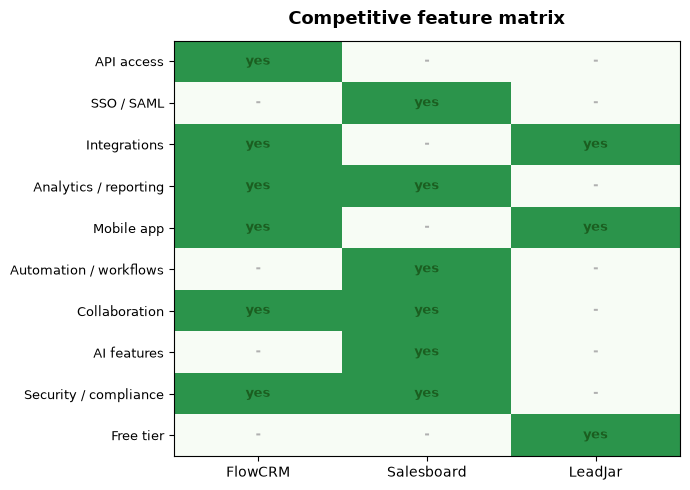

In [4]:
import matplotlib.pyplot as plt
import numpy as np

feats = list(matrix.keys())
grid = np.array([[1 if matrix[f][n] else 0 for n in names] for f in feats])

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(grid, cmap="Greens", vmin=0, vmax=1.4, aspect="auto")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=10)
ax.set_yticks(range(len(feats)))
ax.set_yticklabels(feats, fontsize=9)
for i in range(len(feats)):
    for j in range(len(names)):
        ax.text(j, i, "yes" if grid[i, j] else "-", ha="center", va="center",
                color="#1b5e20" if grid[i, j] else "#b0b0b0", fontsize=9, weight="bold")
ax.set_title("Competitive feature matrix", fontsize=13, weight="bold", pad=12)
plt.tight_layout()
plt.savefig("matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Competitor | Segment | Standout |
|-----------|---------|----------|
| FlowCRM | small teams / startups | broadest features, open pricing |
| Salesboard | mid-market / enterprise | SSO, AI scoring, compliance |
| LeadJar | freelancers / agencies | free forever, cheapest |

The matrix reads as three non-overlapping segments, not a head-to-head fight - useful
positioning intel. And every takeaway traces back to a cell in the grid, so a skeptical
exec can audit it.

In [5]:
# --- Upgrade to Claude (optional) ---
# import os, json, anthropic
#
# def llm_report(competitors, api_key):
#     client = anthropic.Anthropic(api_key=api_key)
#     blob = "\n\n".join(f"### {n}\n{t}" for n, t in competitors.items())
#     resp = client.messages.create(model="claude-sonnet-4-5", max_tokens=2000,
#         messages=[{"role": "user", "content":
#             "Extract each competitor profile + 3-5 strategic takeaways, facts only. JSON.\n" + blob}])
#     return json.loads(resp.content[0].text)
#
# # Claude catches positioning the regex can't - e.g. inferring a "land-and-expand"
# # pricing strategy from a free tier feeding a per-seat paid plan.


In [6]:
# --- Try your own competitors ---
# my = {
#     "Rival A": "paste their site copy / your notes...",
#     "Rival B": "...",
# }
# ps = [extract_profile(n, t) for n, t in my.items()]
# mx = build_feature_matrix(ps)
# for t in takeaways(ps, mx):
#     print("-", t)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 37 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version takes N competitors, renders the matrix as an interactive table, and
lists profiles + takeaways. Add an `ANTHROPIC_API_KEY` for Claude-synthesized takeaways.

*Note: this demo parses text you paste in. For live competitor pages, feed scraped copy
into the same `summarize_competitors` function - scraping is out of scope here to keep the
notebook offline and reproducible.*